# Real-Time Operator Evolution on a Kagome Lattice with Sparse Pauli Dynamics
In the following the Sparse Pauli Dynamics (SPD) method is applied to simulate real-time quantum dynamics on a many-body spin system. Explicitly the time-dependent expectation value $$\langle 0|U^{\dagger}ZU|0 \rangle$$ is computed where $Z$ is the Pauli Z operator acting on the central site of the Kagome lattice, $|0\rangle$ is the all-zero inital state and $U = e^{-iHt}$ is the evolution operator under the 2D transverse-field Hamiltonian $$ H = \sum_{\langle i, j \rangle} Z_i Z_j + h_c \sum_{i} X_i.$$

Motivation of this work was the previous research done in this field by Begušić *et. al.*, which therefore should be considered when going through this code.[1,2]

**In short**: SPD is a classical algorithm for Heisenberg-picture operator evolution that was shown to be faster and than its corresponding quantum experiment. Core idea of the method is that the target observable is represented in the Heisenberg picture as a sum of Pauli operators where terms with small coefficients are truncated systematically avoiding the simulation to explode.

> **Note**: to make sure that this code runs on your device, please install the needed package as described below.

In [ ]:
try:
    from spd.SparsePauliDynamics import *
    from spd.BaseOperatorRepresentation import * 
except ImportError:
    print("\n" + "="*60)
    print("REQUIRED PACKAGE 'spd' NOT FOUND")
    print("="*60)
    print("This notebook relies on the 'spd' package.")
    print("Please install it before proceeding:\n")
    print("   pip install git+https://github.com/tbegusic/spd.git")
    print("="*60 + "\n")
    raise

import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.hamiltonians.lattices import (
    KagomeLattice,
    BoundaryCondition,
)
from qiskit.quantum_info import SparsePauliOp


REQUIRED PACKAGE 'spd' NOT FOUND
This notebook relies on the 'spd' package.
Please install it before proceeding:

   pip install git+https://github.com/tbegusic/spd.git

See the README.md file for detailed setup instructions.



ModuleNotFoundError: No module named 'spd'

The Kagome lattice itself with its boundary conditions is implemented by making use of Qiskit Nature.\
The lattice contains in this case 3 unit cells in x- and 2 in y-direction with 3 sites per unit cell making it 18 sites in total. This is only due to technical purposes, so that the code is able to run faster than with larger lattices. \
The nearest neighbours are then computed by taking the weighted edges and then making a list of neighbours while making sure the each neighbor bond appears once.

In [ ]:
Lx, Ly = 3, 2
kagome = KagomeLattice(rows=Lx, cols=Ly,
    boundary_condition=(BoundaryCondition.PERIODIC, BoundaryCondition.PERIODIC)
)
nq = kagome.num_nodes
weighted_edges = kagome.weighted_edge_list
nlist = [(i, j) for i, j, _ in weighted_edges if i != j]

As gone through previously, now the Hamiltonian and the observable are implemented using SparsePauliOp.\
The ciritical point $h_c$ is arbitrarily set to 1.


In [ ]:
hc = 1
h = hc
hzz = SparsePauliOp.from_sparse_list([("ZZ", pair, 1.0) for pair in nlist], num_qubits=nq)
hx = SparsePauliOp.from_sparse_list([("X", [i], h) for i in range(nq)], num_qubits=nq)
h_tot = hzz + hx
obs = SparsePauliOp.from_sparse_list([("Z", [(nq-1)//2], 1.0)], num_qubits=nq)

The total time is set to 1 and $\Delta t$ to 0.02 (time step) leading to 50 steps in total.

In [9]:
step = 1
dt = 0.02
nsteps = int(step/dt)

This function computes the expectation value of a $Z$-type Pauli observable on the all-zero state. In the case of a Pauli string consisting only of $I$ and $Z$, the expectation value is defined as the sum of its coefficients.\
The print lets you have an insight into the growth of the current numbers of Paulis.\
Storing copies of the observable at each time is a convention which ensures that when the simulation is run for multiple thresholds, the data from each threshold remains independent from later runs.

In [10]:
obs_t = [] #to store copies of obs at each time
def exp_val_func(obs):
    obs_t.append(obs.copy())
    exp_val = np.sum(obs.coeffs[obs.ztype()])
    print(exp_val, obs.size)
    return exp_val

The Hamiltonian is multiplied by $\Delta t$ to form the Trotter steps.\
Then a threshold $\delta$ is defined. It is set to $2^{-12}$ just so that it runs easily on your local device.\
The third line is called before the simulation to ensure that if the cell is re-run (in case of multiple thresholds), data from previous runs are not mixed with each other.\
An SPD 'Simultation' object is created from the inital observable and the list of Pauli rotation operators. The simulation will truncate Pauli terms whose coefficient magnitudes falls below the given threshold at each time step.\
The dynamics is then run and the results are stored and plotted with respect to time.


In [ ]:
ops = dt*h_tot 
threshold = 2.**-12
obs_t.clear()
sim = Simulation.from_pauli_list(obs, ops, threshold=threshold, nprocs=1)
r = sim.run_dynamics(nsteps, process=exp_val_func, process_every = step)
results = np.array(r)

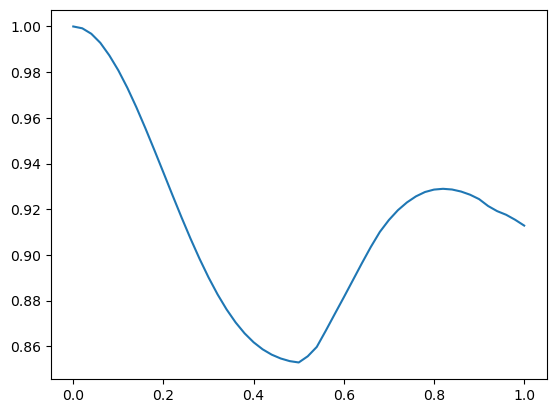

In [ ]:
plt.plot(np.arange(len(results))*dt, results)
plt.show()

## References 
[1] Begušić, Tomislav, Johnnie Gray, and Garnet Kin-Lic Chan. “Fast and Converged Classical Simulations of Evidence for the Utility of Quantum Computing before Fault Tolerance.” Science Advances 10, no. 3 (2024): eadk4321. https://doi.org/10.1126/sciadv.adk4321. \
[2] Begušić, Tomislav, und Garnet Kin-Lic Chan. „Real-Time Operator Evolution in Two and Three Dimensions via Sparse Pauli Dynamics“. PRX Quantum 6, Nr. 2 (2025): 020302. https://doi.org/10.1103/PRXQuantum.6.020302.

